<a href="https://colab.research.google.com/github/Shivangi144/Projects/blob/main/ds_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

/tmp/ipykernel_2391/3078318250.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)
/tmp/ipykernel_2391/3078318250.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

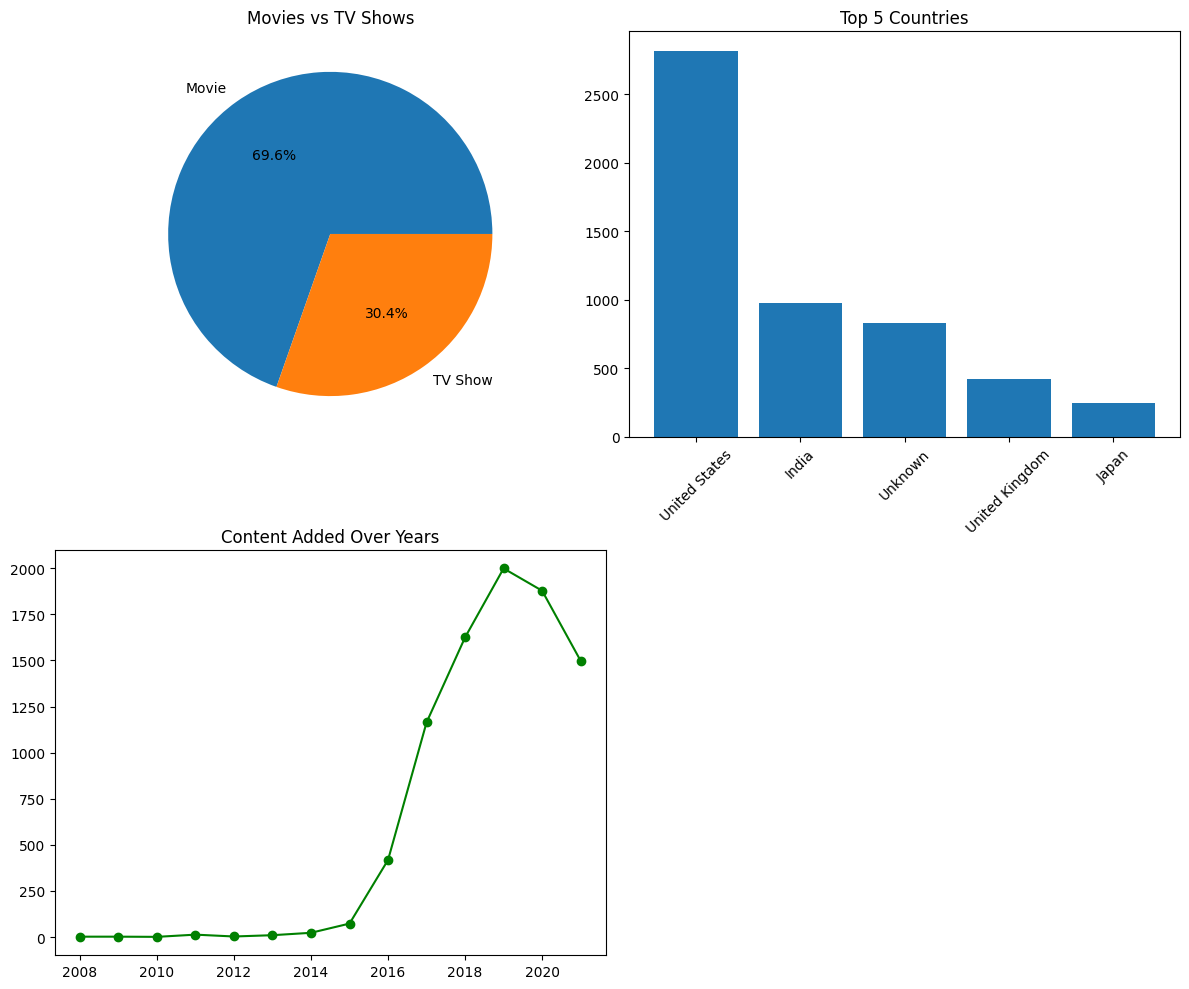


Model Accuracy: 0.699205448354143

Confusion Matrix:
[[1159   55]
 [ 475   73]]

Predicted Type: Movie


/tmp/ipykernel_2391/3078318250.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['type'] = le_type.fit_transform(df_model['type'])
/tmp/ipykernel_2391/3078318250.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['country'] = le_country.fit_transform(df_model['country'])
/tmp/ipykernel_2391/3078318250.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

#
df = pd.read_csv("netflix_titles.csv")

print("First 5 rows:")
print(df.head())

#handle missing values
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Not Available", inplace=True)
df['country'].fillna("Unknown", inplace=True)
df['rating'].fillna("Not Rated", inplace=True)
print(df)

# Convert date
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year


# Movies vs TV Shows
type_counts = df['type'].value_counts()

# Top Countries
top_countries = df['country'].value_counts().head(5)

# Content added per year
year_counts = df['year_added'].value_counts().sort_index()

#subplots
plt.figure(figsize=(12,10))

# Pie Chart
plt.subplot(2,2,1)
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%')
plt.title("Movies vs TV Shows")

# Bar Chart
plt.subplot(2,2,2)
plt.bar(top_countries.index, top_countries.values)
plt.title("Top 5 Countries")
plt.xticks(rotation=45)

# Line Chart
plt.subplot(2,2,3)
plt.plot(year_counts.index, year_counts.values, marker='o',color='green')
plt.title("Content Added Over Years")

plt.tight_layout()
plt.show()

# predict data
df_model = df[['type', 'country', 'rating']]

# Encoding
le_type = LabelEncoder()
le_country = LabelEncoder()
le_rating = LabelEncoder()

df_model['type'] = le_type.fit_transform(df_model['type'])
df_model['country'] = le_country.fit_transform(df_model['country'])
df_model['rating'] = le_rating.fit_transform(df_model['rating'])

# Features & Target
X = df_model[['country', 'rating']]
y = df_model['type']

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model train
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

#
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

#
new_data = pd.DataFrame({
    "country": ["India"],
    "rating": ["TV-MA"]
})

# Encode
new_data['country'] = le_country.transform(new_data['country'])
new_data['rating'] = le_rating.transform(new_data['rating'])

# Scale
new_data = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data)

result = le_type.inverse_transform(prediction)
print("\nPredicted Type:", result[0])